# Ejercicio 2 - 29 de Abril

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co

Tiempo **30 minutos**.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)
---

**Referencia:** Matejka, J. & Fitzmaurice, G. (2017). *Same stats, different graphs: generating datasets
with varied appearance and identical statistics through simulated annealing.*
ACM CHI 2017 (Honorable Mention). https://www.research.autodesk.com/publications/same-stats-different-graphs/

---

### Contexto

El cuarteto de Anscombe (1973) demostró que cuatro datasets con **estadísticas idénticas** pueden tener
distribuciones radicalmente distintas. Matejka & Fitzmaurice (2017) llevaron esto al extremo.

## Parte 0 · Configuración

In [34]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib as mpl
from matplotlib import pyplot as plt

from scipy import stats as sp
import numpy as np

mpl.rcParams.update({
    "text.usetex": True,            # Activa el renderizado de LaTeX
    "font.family": "serif",         # Usa familia serif
    "font.serif": ["Computer Modern Roman"], # Fuente clásica de LaTeX
    "font.size": 14,                # Tamaño de fuente general más grande

    # Ejes y Ticks
    "axes.labelsize": 16,           # Tamaño de etiquetas (x, y)
    "axes.titlesize": 18,           # Tamaño del título
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,    # Mostrar ticks menores en X
    "ytick.minor.visible": True,    # Mostrar ticks menores en Y
    "xtick.direction": "in",        # Ticks hacia adentro (estilo clásico)
    "ytick.direction": "in",

    # Estética de la figura
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

print('Configuración OK')

Configuración OK


---
## Parte 1 · Punto de partida: estadísticas no dicen todo

Primero vamos a reproducir el argumento central del paper:
calcular estadísticas de varios datasets y mostrar que son idénticas
— *antes* de graficarlos.

In [35]:
# Cuarteto de Anscombe: 4 datasets con estadísticas casi idénticas pero distribuciones muy distintas
anscombe = {
    '1':   {'x': [10,8,13,9,11,14,6,4,12,7,5],       # x compartido por I, II y III
            'y': [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]},  # relación lineal con ruido
    '2':  {'x': [10,8,13,9,11,14,6,4,12,7,5],
            'y': [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]},  # relación cuadrática
    '3': {'x': [10,8,13,9,11,14,6,4,12,7,5],
            'y': [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]},  # outlier en y (12.74)
    '4':  {'x': [8,8,8,8,8,8,8,19,8,8,8],            # x constante excepto un outlier (19)
            'y': [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]},  # outlier en x controla la regresión
}

# Encabezado de la tabla: >N alinea a la derecha en N caracteres
print(f"{'Dataset':>10} {'media x':>9} {'media y':>9} {'sd x':>7} {'sd y':>7} {'r':>7} {'pendiente':>10}")
print('-' * 65)  # separador de ancho igual al de la línea más larga

for name, d in anscombe.items():
    x, y = np.array(d['x']), np.array(d['y'])          # listas → arrays para operar vectorialmente
    slope, intercept, r, _, _ = sp.linregress(x, y)    # regresión OLS; descarta p-value y stderr con _
    print(f"{'Dataset '+name:>10} {x.mean():>9.2f} {y.mean():>9.2f} "   # medias con 2 decimales
          f"{x.std(ddof=1):>7.2f} {y.std(ddof=1):>7.2f} "               # ddof=1: desviación estándar muestral
          f"{r:>7.3f} {slope:>10.3f}")                                  # r de Pearson y pendiente con 3 decimales


   Dataset   media x   media y    sd x    sd y       r  pendiente
-----------------------------------------------------------------
 Dataset 1      9.00      7.50    3.32    2.03   0.816      0.500
 Dataset 2      9.00      7.50    3.32    2.03   0.816      0.500
 Dataset 3      9.00      7.50    3.32    2.03   0.816      0.500
 Dataset 4      9.00      7.50    3.32    2.03   0.817      0.500


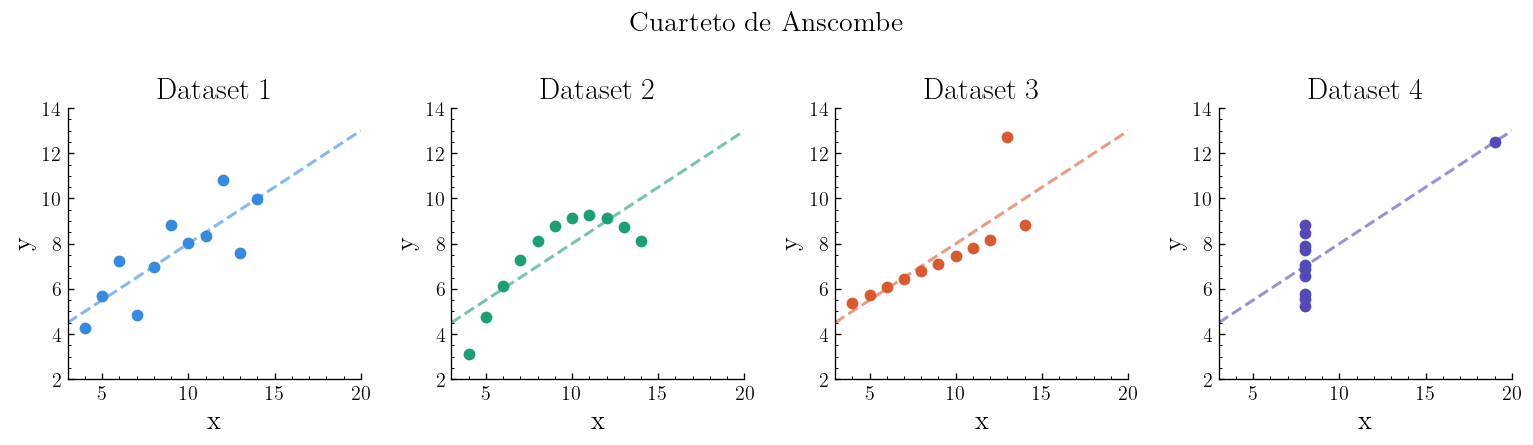

In [36]:
# Ahora graficarlos — el punto de Anscombe
fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))
colors = ['#378ADD', '#1D9E75', '#D85A30','#534AB7']
x_line = np.linspace(3, 20, 200)

for ax, (name, d), c in zip(axes, anscombe.items(), colors):
    x, y = np.array(d['x']), np.array(d['y'])
    slope, intercept, r, _, _ = sp.linregress(x, y)

    ax.scatter(x, y, color=c, s=50, zorder=3, linewidths=0)
    ax.plot(x_line, slope*x_line + intercept, color=c, lw=1.8, alpha=0.6, ls='--')

    ax.set(xlim=(3,20), ylim=(2,14), title=f'Dataset {name}',
           xlabel='x', ylabel='y')

fig.suptitle('Cuarteto de Anscombe')
plt.tight_layout()
plt.show()


---
## Parte 2 · Un experimento extremo

Consideremos la siguiente nube de datos:

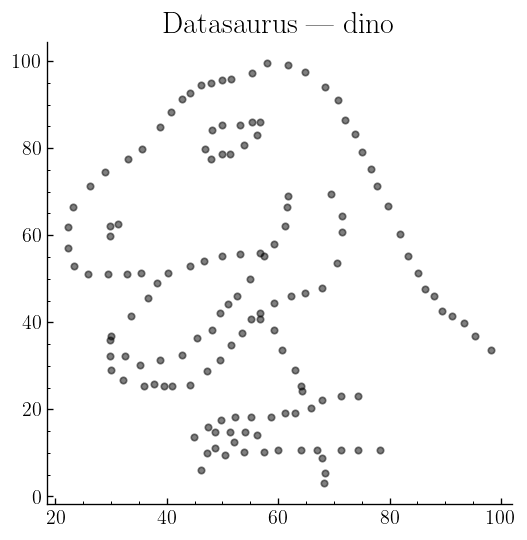

estadística               valor
--------------------------------
media x                   54.26
media y                   47.83
sd x                      16.77
sd y                      26.94
r de Pearson             -0.064
pendiente                -0.104
intercepto               53.453


In [37]:
import pandas as pd

df = pd.read_csv('datasaurus.csv')                      # carga el archivo completo
dino = df[df['dataset'] == 'dino']                      # filtra solo el dataset 'dino'

x_dino, y_dino = dino['x'].values, dino['y'].values               # extrae x e y como arrays numpy
slope, intercept, r, _, _ = sp.linregress(x_dino, y_dino)         # regresión OLS

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_dino, y_dino, s=15, alpha=0.5, color='k')                       # scatter con puntos pequeños

#ax.axis('equal')
ax.set_title('Datasaurus — dino')
plt.show()


# ── tabla de estadísticas ────────────────────────────────────────────────────
print(f"{'estadística':<20} {'valor':>10}")
print('-' * 32)
print(f"{'media x':<20} {x_dino.mean():>10.2f}")
print(f"{'media y':<20} {y_dino.mean():>10.2f}")
print(f"{'sd x':<20} {x_dino.std(ddof=1):>10.2f}")
print(f"{'sd y':<20} {y_dino.std(ddof=1):>10.2f}")
print(f"{'r de Pearson':<20} {r:>10.3f}")
print(f"{'pendiente':<20} {slope:>10.3f}")
print(f"{'intercepto':<20} {intercept:>10.3f}")



# ¿Somos capaces de construir otro(s) dataset(s) con las mismas estadísticas que Dino?

## Estadísticas objetivo
| Estadístico | Valor |
|---|---|
| $\bar{x}$ | 54.26 |
| $\bar{y}$ | 47.83 |
| $s_x$ | 16.76 |
| $s_y$ | 26.93 |
| $r$ (Pearson) | −0.06 |

En el paper de 2017 **simulated annealing**: un algoritmo de optimización que perturba los puntos
iterativamente hacia una forma objetivo, aceptando solo movimientos que mantengan las estadísticas
dentro de un margen de tolerancia.

## Vamos a implementar ese algoritmo desde cero.

El algoritmo en cada iteración:

1. Elige un punto al azar (del dataset a modificar)
2. Lo mueve una pequeña cantidad aleatoria
3. Verifica que las 5 estadísticas sigan siendo correctas (hasta 2 decimales)
4. Si las estadísticas están bien, evalúa si el punto se acercó a la forma objetivo:
   - Si se acercó → acepta el movimiento
   - Si se alejó → acepta con probabilidad $e^{-\Delta/T}$ (la temperatura $T$ baja con el tiempo)
5. Si las estadísticas fallaron → rechaza el movimiento (restaura el punto)

El término $e^{-\Delta/T}$ es el **simulated annealing**: al inicio acepta algunos movimientos
"malos" para escapar de mínimos locales; al final se vuelve más estricto.


### ¿Qué significa 'verificar que las estadísticas son correctas'?

El paper usa tolerancia de **dos decimales**: redondea cada estadístico a 2 decimales y verifica
que coincida con el valor objetivo.

$$|\text{round}(\bar{x}, 2) - 54.26| < \epsilon$$

### ¿Cuáles son las formas 'objetivo'?

- Para un círculo: distancia al perímetro $= |\sqrt{(x-c_x)^2 + (y-c_y)^2} - r|$
- Para líneas horizontales: distancia a la línea más cercana $= \min_k |y - y_k|$
- Para la forma X: distancia a las diagonales

In [38]:
# ─── Función de verificación de estadísticas ─────────────────────────────────
target = dict(xm=54.26, ym=47.83, xs=16.76, ys=26.93, r=-0.06)

def stats_ok(x, y, target, eps=0.005):
    """
    Verifica que x, y cumplan las 5 estadísticas objetivo.
    eps=0.005 equivale a tolerancia de 2 decimales.
    """
    r = np.corrcoef(x, y)[0, 1]
    return (
        abs(x.mean()      - target['xm']) < eps and
        abs(y.mean()      - target['ym']) < eps and
        abs(x.std(ddof=1) - target['xs']) < eps and
        abs(y.std(ddof=1) - target['ys']) < eps and
        abs(r             - target['r'])  < eps
    )

In [39]:
cx, cy = target['xm'], target['ym']  # centro de la distribución

# ─── Formas provistas ────────────────────────────────────────────────────────
def circulo(xi, yi, radio=22):
    """Distancia al perímetro de un círculo centrado en (cx, cy)."""
    return abs(np.sqrt((xi - cx)**2 + (yi - cy)**2) - radio)

def lineas_h(xi, yi):
    """Distancia a la línea horizontal más cercana (3 líneas equiespaciadas)."""
    ys = [cy - 20, cy, cy + 20]
    return min(abs(yi - yy) for yy in ys)

def forma_x(xi, yi):
    """Distancia a las dos diagonales que forman una X centrada en (cx, cy)."""
    dx, dy = xi - cx, yi - cy
    return min(abs(dy - dx), abs(dy + dx)) / np.sqrt(2)

## Función de perturbaciones

```python
    def perturb(x, y, target, temperature, shape_dist, rng, max_tries=100):
    """
    Intenta mover un punto al azar hacia la forma objetivo.

    Parámetros
    ----------
    x, y         : arrays de puntos actuales
    target       : dict con estadísticas objetivo
    temperature  : temperatura actual del annealing (entre 1 y 0)
    shape_dist   : función f(xi, yi) -> distancia al objetivo (menor = más cerca)
    rng          : generador de números aleatorios numpy
    max_tries    : intentos máximos antes de devolver sin cambios

    Retorna
    -------
    x, y actualizados (o sin cambio si no se encontró movimiento válido)
    """
```

In [40]:
def perturb(x, y, target, temperature, shape_dist, rng, max_tries=100):

    x, y = x.copy(), y.copy()
    n = len(x)

    for _ in range(max_tries):

        # 1. Elegir punto aleatorio
        i = rng.integers(n)
        xi_old, yi_old = x[i], y[i]

        # 2. Mover con ruido gaussiano pequeño
        x[i] += rng.normal(0, 1)
        y[i] += rng.normal(0, 1)

        # 3. Verificar estadísticas — si fallan, revertir y reintentar
        if not stats_ok(x, y, target):
            x[i], y[i] = xi_old, yi_old
            continue

        # 4. Evaluar si nos acercamos a la forma objetivo
        d_old = shape_dist(xi_old, yi_old)
        d_new = shape_dist(x[i],   y[i])
        delta = d_new - d_old   # delta < 0 = nos acercamos

        # Criterio de Metropolis (simulated annealing)
        if delta < 0 or rng.random() < np.exp(-delta / max(temperature, 1e-10)):
            return x, y         # aceptado
        else:
            x[i], y[i] = xi_old, yi_old  # rechazado

    return x, y

## Función principal

```python
    def run_annealing(x0, y0, target, shape_dist,
                  n_iters=100000):
    """
    Ejecuta el simulated annealing de Matejka et al. (2017).

    Parámetros
    ----------
    x0, y0      : dataset inicial (nube de puntos con estadísticas correctas)
    target      : dict con estadísticas objetivo
    shape_dist  : función de distancia a la forma objetivo
    n_iters     : número de iteraciones

    Retorna
    -------
    x, y : arrays finales
    """
```

In [41]:
def run_annealing(x0, y0, target, shape_dist,n_iters=100000):

    rng = np.random.default_rng(1234)
    x, y = x0.copy(), y0.copy()
    snapshots = []

    for i in range(n_iters):
        # Temperatura decrece linealmente de 1 a 0
        temperature = max(0.0, 1.0 - i / n_iters)
        x, y = perturb(x, y, target, temperature, shape_dist, rng)

        if i % (n_iters // 5) == 0:
            snapshots.append((i, x.copy(), y.copy()))

    return x, y , snapshots

In [42]:
# Ejecutar el annealing para cada forma
N_ITERS = 20000

print('=== Círculo ===')
x_circ, y_circ, snaps_circ = run_annealing(x_dino, y_dino, target, circulo,
                                            n_iters=N_ITERS)

print('\n=== Líneas horizontales ===')
x_lin, y_lin, snaps_lin = run_annealing(x_dino, y_dino, target, lineas_h,
                                         n_iters=N_ITERS)

print('\n=== Forma X ===')
x_x, y_x, snaps_x = run_annealing(x_dino, y_dino, target, forma_x,
                                   n_iters=N_ITERS)


# Verificar que las estadísticas se conservaron
print(f"{'Forma':>12} {'x̄':>7} {'ȳ':>7} {'sx':>7} {'sy':>7} {'r':>7} {'ok':>5}")
print('-' * 55)
for name, (x, y) in [('Dino', (x_dino, y_dino)),
                       ('Círculo',     (x_circ, y_circ)),
                       ('Líneas',      (x_lin,  y_lin)),
                       ('Forma X',     (x_x,    y_x))]:
    r = np.corrcoef(x, y)[0, 1]
    ok = stats_ok(x, y, target)
    print(f'{name:>12} {x.mean():>7.2f} {y.mean():>7.2f} '
          f'{x.std(ddof=1):>7.2f} {y.std(ddof=1):>7.2f} '
          f'{r:>7.2f} {str(ok):>5}')

=== Círculo ===

=== Líneas horizontales ===

=== Forma X ===
       Forma      x̄       ȳ      sx      sy       r    ok
-------------------------------------------------------
        Dino   54.26   47.83   16.77   26.94   -0.06 False
     Círculo   54.26   47.83   16.76   26.93   -0.06  True
      Líneas   54.26   47.83   16.76   26.93   -0.06  True
     Forma X   54.26   47.83   16.76   26.93   -0.06  True


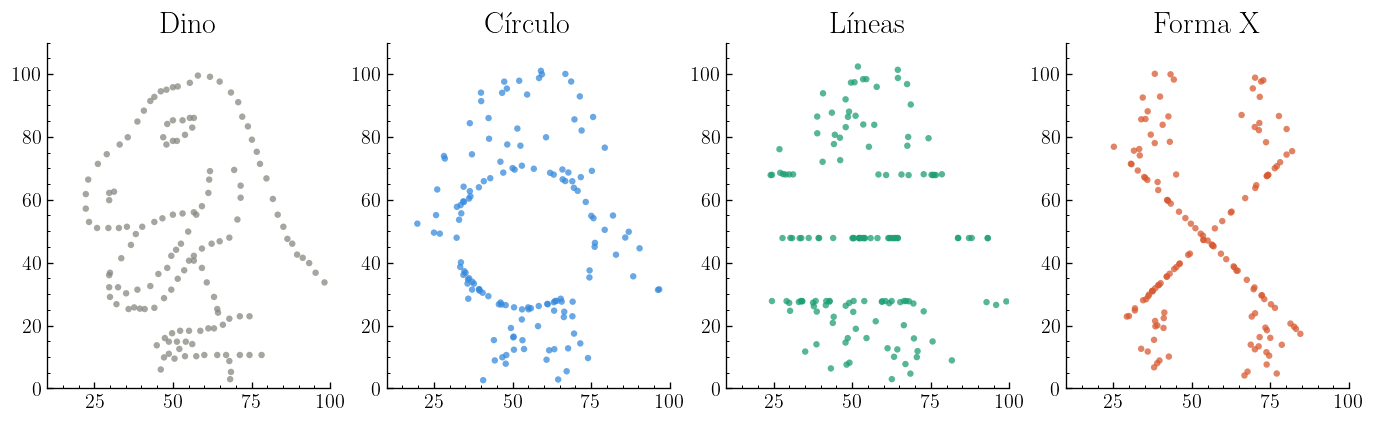

In [43]:
# ─── Figura principal: nube → 3 formas ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
C = ['#888780', '#378ADD', '#1D9E75', '#D85A30']

datasets = [
    ('Dino', x_dino, y_dino),
    ('Círculo', x_circ, y_circ),
    ('Líneas', x_lin,  y_lin),
    ('Forma X',x_x, y_x),
]

for ax, (name, x, y), c in zip(axes, datasets, C):
    ax.scatter(x, y, s=15, alpha=0.75, color=c, edgecolors='none')
    ax.set_title(name)

    ax.set_xlim(10, 100); ax.set_ylim(0, 110)
    ax.set_aspect('equal')

plt.show()

# # ─── Secuencia de snapshots del annealing ────────────────────────────────────
# shapes = [
#     ('Círculo',  snaps_circ, '#378ADD'),
#     ('Líneas',   snaps_lin,  '#1D9E75'),
#     ('Forma X',  snaps_x,    '#D85A30'),
# ]

# n_snaps = len(snaps_circ)
# fig, axes = plt.subplots(3, n_snaps, figsize=(3.2 * n_snaps, 9),
#                          sharex=True, sharey=True)

# for row, (name, snaps, color) in enumerate(shapes):
#     for col, (iteration, xs, ys) in enumerate(snaps):
#         ax = axes[row, col]
#         ax.scatter(xs, ys, s=8, alpha=0.6, color=color, edgecolors='none')
#         ax.set_xlim(10, 100)
#         ax.set_ylim(0, 110)
#         ax.set_aspect('equal')
#         if row == 0:
#             ax.set_title(f'iter {iteration:,}', fontsize=12)
#         if col == 0:
#             ax.set_ylabel(name, fontsize=13)

# fig.suptitle('Evolución del annealing por forma', y=1.01)
# plt.tight_layout()
# plt.show()

---
## Referencias

- Matejka, J. & Fitzmaurice, G. (2017). Same stats, different graphs. *ACM CHI 2017*. https://www.research.autodesk.com/publications/same-stats-different-graphs/
- Anscombe, F. J. (1973). Graphs in statistical analysis. *American Statistician*, 27, 17–21.
- [https://www.kaggle.com/datasets/tombutton/datasaurusdozen?resource=download](https://www.kaggle.com/datasets/tombutton/datasaurusdozen?resource=download)
---
*Programación Científica 2026-1 · Universidad Nacional de Colombia · mbastidaso@unal.edu.co*